# Setup:

In [285]:
# ── All imports in one place ──────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    classification_report
)

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


print('Ready ✅')

Ready ✅


In [286]:
# Load dataset — each row is a student, each column is a feature
df = pd.read_csv('game_characters.csv')
print(f'Dataset: {df.shape[0]} , {df.shape[1]} columns')
df.head(8)

Dataset: 300 , 10 columns


,race,level,strength,agility,intellect,stamina,magic_affinity,years_training,power_score,role
0,Human,40,70,53,49,75,0.06,22,480.6,Warrior
1,Orc,11,67,49,46,70,0.19,22,408.8,Warrior
2,Human,48,39,42,79,38,0.88,29,594.5,Mage
3,Orc,32,12,40,77,37,0.89,9,442.7,Mage
4,Dragon,36,74,55,27,66,0.19,9,480.9,Warrior
5,Orc,33,20,42,64,54,0.71,3,426.4,Healer
6,Elf,24,34,98,56,54,0.23,7,401.0,Archer
7,Orc,39,26,86,37,61,0.23,21,483.3,Archer


# Task1 : label encoder for race column

In [287]:
# 0 Dragon , 1 Dwarf , 2 Elf , 3 Human , 4 Orc
from sklearn.preprocessing import LabelEncoder

game_characters_enc = df.copy()
le = LabelEncoder()

game_characters_enc['race'] = le.fit_transform(game_characters_enc['race'])

game_characters_enc.head(10)

,race,level,strength,agility,intellect,stamina,magic_affinity,years_training,power_score,role
0,3,40,70,53,49,75,0.06,22,480.6,Warrior
1,4,11,67,49,46,70,0.19,22,408.8,Warrior
2,3,48,39,42,79,38,0.88,29,594.5,Mage
3,4,32,12,40,77,37,0.89,9,442.7,Mage
4,0,36,74,55,27,66,0.19,9,480.9,Warrior
5,4,33,20,42,64,54,0.71,3,426.4,Healer
6,2,24,34,98,56,54,0.23,7,401.0,Archer
7,4,39,26,86,37,61,0.23,21,483.3,Archer
8,1,34,73,80,44,60,0.05,19,457.4,Archer
9,4,28,26,34,66,49,0.78,19,473.2,Healer


## make standard scaler:

In [288]:

# Select numerical columns (excluding the target/categorical columns if needed)
numerical_cols = ['level', 'strength', 'agility', 'intellect', 'stamina',
                   'magic_affinity', 'years_training' ]

scaler = StandardScaler()

game_characters_scaled = game_characters_enc.copy()
game_characters_scaled[numerical_cols] = scaler.fit_transform(game_characters_scaled[numerical_cols])

game_characters_scaled.head(20)

,race,level,strength,agility,intellect,stamina,magic_affinity,years_training,power_score,role
0,3,0.948822,0.942784,0.070327,-0.240693,1.325216,-1.208083,0.909347,480.6,Warrior
1,4,-1.021756,0.811538,-0.136518,-0.395646,1.009839,-0.798279,0.909347,408.8,Warrior
2,3,1.492429,-0.413425,-0.498497,1.308835,-1.008577,1.376839,1.752450,594.5,Mage
3,4,0.405214,-1.594639,-0.601919,1.205533,-1.071653,1.408362,-0.656416,442.7,Mage
4,0,0.677018,1.117778,0.173750,-1.377014,0.757537,-0.798279,-0.656416,480.9,Warrior
5,4,0.473165,-1.244650,-0.498497,0.534071,0.000631,0.840940,-1.379076,426.4,Healer
6,2,-0.138393,-0.632168,2.397335,0.120863,0.000631,-0.672185,-0.897303,401.0,Archer
7,4,0.880871,-0.982158,1.776799,-0.860505,0.442159,-0.672185,0.788904,483.3,Archer
8,1,0.541116,1.074030,1.466532,-0.498948,0.379084,-1.239607,0.548017,457.4,Archer
9,4,0.133410,-0.982158,-0.912187,0.637373,-0.314747,1.061604,0.548017,473.2,Healer


# Task 3 :

##ploting:

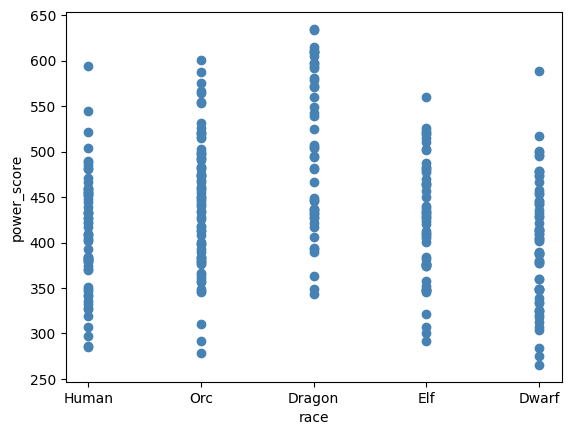

In [289]:
# Quick look at both features vs Salary
plt.scatter(df['race'], df['power_score'], color='steelblue')
plt.xlabel('race')
plt.ylabel('power_score')
plt.show()

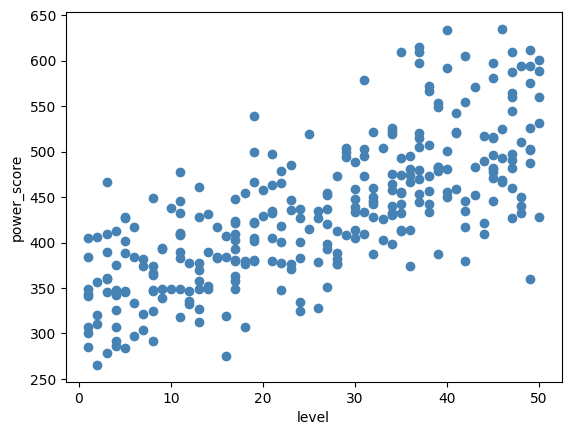

In [290]:
# Quick look at both features vs Salary
plt.scatter(df['level'], df['power_score'], color='steelblue')
plt.xlabel('level')
plt.ylabel('power_score')
plt.show()

## Linear Regrassion  :

In [291]:
from sklearn.model_selection import train_test_split
X = game_characters_scaled[['race', 'level', 'strength', 'agility','intellect','stamina','magic_affinity','years_training']]
y = game_characters_scaled['power_score']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print(f'Train: {len(X_train)} rows  |  Test: {len(X_test)} rows')

Train: 240 rows  |  Test: 60 rows


In [292]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"R²:   {r2:.3f}")

print("\nIntercept:", model.intercept_)
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:<16} {coef:.4f}")

RMSE: 28.034
MAE:  23.858
R²:   0.881

Intercept: 447.85118542773984
  race             -6.7677
  level            54.8039
  strength         22.4315
  agility          15.0065
  intellect        22.7517
  stamina          10.8600
  magic_affinity   32.4802
  years_training   33.3601


### decision tree regressor

In [293]:
# ============================================================
# Task 3 — Regression: Predict power_score
# ============================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# 1. تحميل البيانات
df = pd.read_csv('game_characters.csv')

X = df[['race', 'level', 'strength', 'agility','intellect','stamina','magic_affinity','years_training']]
X = pd.get_dummies(X, columns=['race'], drop_first=False)  # encode race
y = df['power_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = {}

# ============================================================
# 2. Linear Regression
# ============================================================
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)
results['Linear Regression'] = r2_score(y_test, y_pred_lin)

# ============================================================
# 3. Polynomial Regression (degree 2)
# ============================================================
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)
results['Polynomial Regression (deg=2)'] = r2_score(y_test, y_pred_poly)

# ============================================================
# 4. Decision Tree Regressor
# ============================================================
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)
results['Decision Tree Regressor'] = r2_score(y_test, y_pred_tree)

# ============================================================
# 5. Compare R² scores
# ============================================================
print("R² Score Comparison:")
for model, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {model:<30} {score:.4f}")

R² Score Comparison:
  Linear Regression              0.9812
  Polynomial Regression (deg=2)  0.9695
  Decision Tree Regressor        0.8244


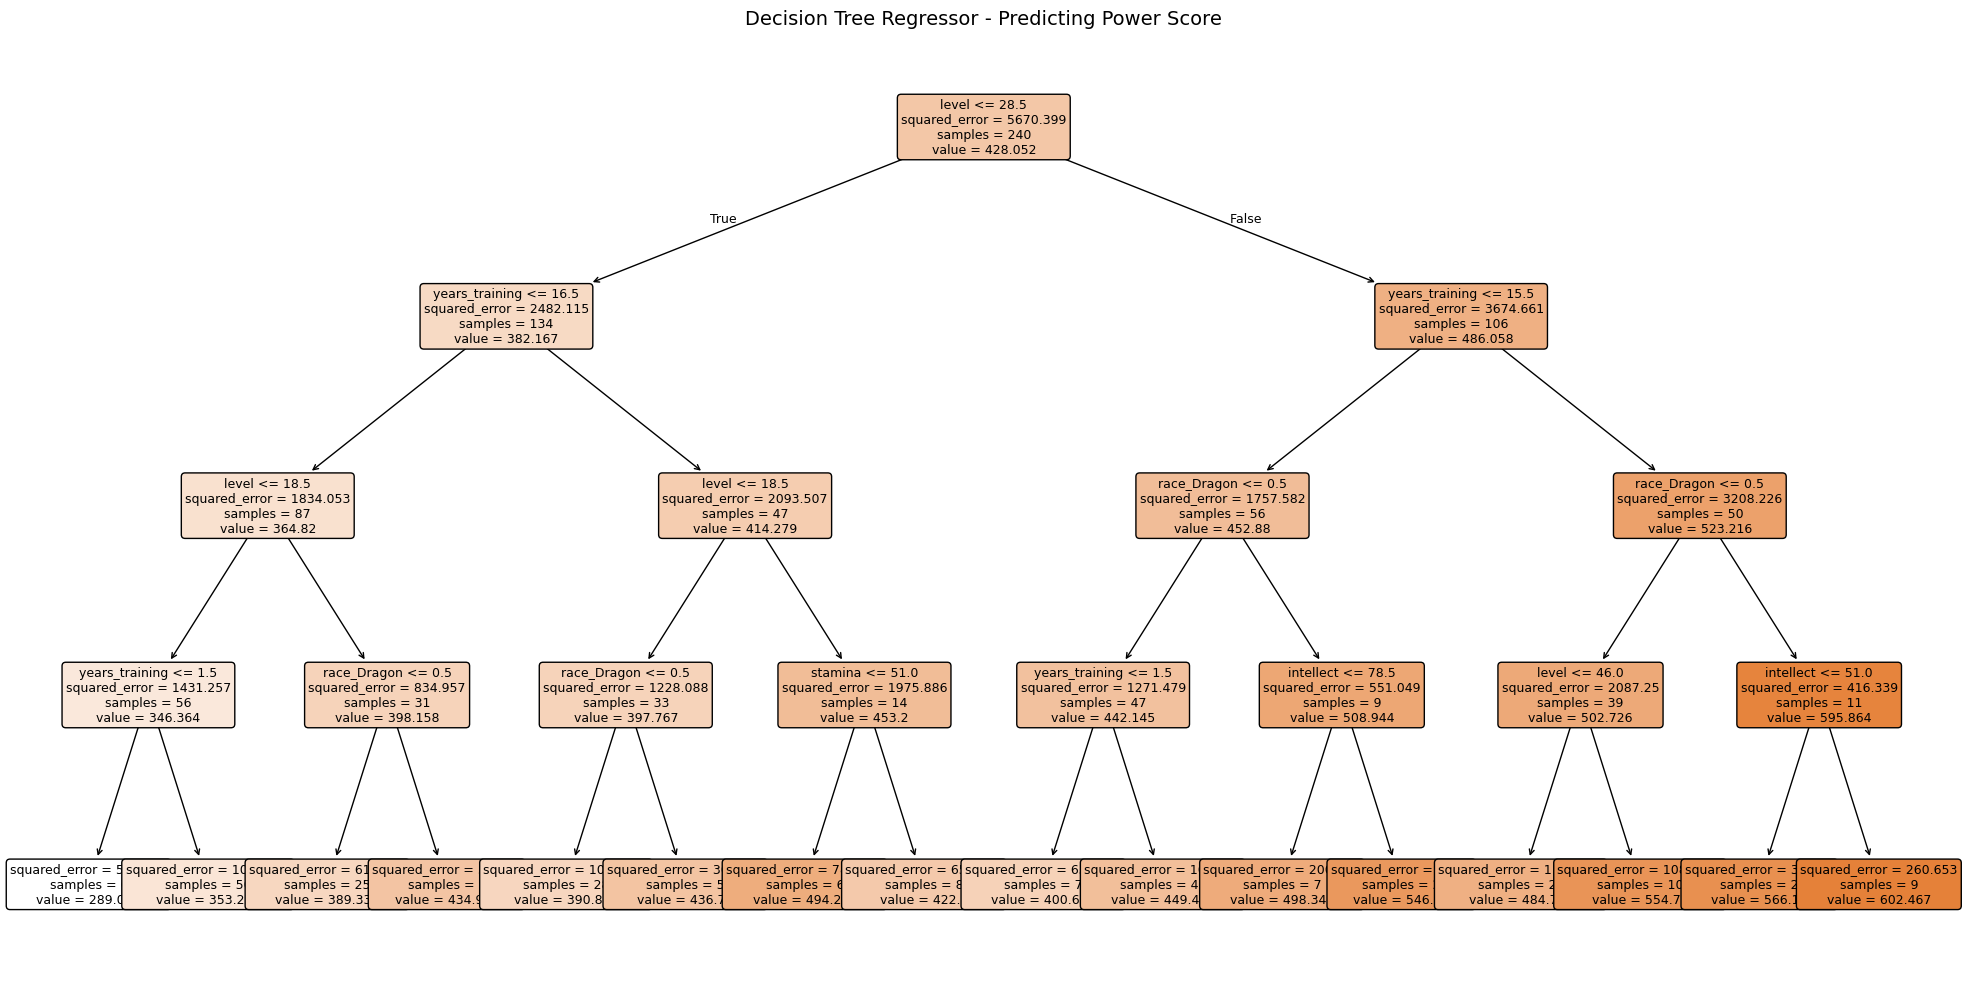

In [294]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree_reg,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Regressor - Predicting Power Score", fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_regressor.png', dpi=150, bbox_inches='tight')
plt.show()

In [313]:
def predict_score(race, level, strength, agility, intellect, stamina, magic_affinity, years_training):
    # Build a single-row DataFrame with the same raw columns used in training
    new_char = pd.DataFrame([{
        'race': race,
        'level': level,
        'strength': strength,
        'agility': agility,
        'intellect': intellect,
        'stamina': stamina,
        'magic_affinity': magic_affinity,
        'years_training': years_training
    }])

    # One-hot encode race the same way as training data
    new_char = pd.get_dummies(new_char, columns=['race'], drop_first=False)

    # Align columns with X_train — adds any missing race_* columns as 0,
    # drops any extra ones, and keeps the exact same column order
    new_char = new_char.reindex(columns=X_train.columns, fill_value=0)

    # Predict using whichever regressor you want (e.g. rf_reg, tree_reg, lin_reg)
    prediction = rf_reg.predict(new_char)[0]
    return prediction

# Example usage
score = predict_score(
    race='Elf',
    level=40,
    strength=70,
    agility=50,
    intellect=45,
    stamina=75,
    magic_affinity=0.3,
    years_training=20
)
print(f"Predicted power_score: {score:.2f}")

Predicted power_score: 497.63


# Task4:

## multi _ Class _ classification:

In [299]:
# How many students per grade?
df['role'].value_counts()

,count
role,
Warrior,92
Archer,73
Healer,69
Mage,66


In [300]:
# Prepare features and target for multi-class
# Features (X) = what the model uses to make a prediction
# Target (y)   = what we want to predict

X = game_characters_scaled[['race', 'level', 'strength', 'agility','intellect','stamina','magic_affinity','years_training']]
y = game_characters_scaled['role']

# Split: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 240
Testing  samples : 60


In [301]:
# Train a Logistic Regression model on 4 classes
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

print('Predictions for the first 10 test students:')
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10]})
print(f'Actual: {y_test.values[:10]}')
print(f'Predicted: {y_pred[:10]}')


Predictions for the first 10 test students:
Actual: ['Healer' 'Archer' 'Archer' 'Archer' 'Archer' 'Archer' 'Mage' 'Archer'
 'Warrior' 'Archer']
Predicted: ['Healer' 'Archer' 'Archer' 'Archer' 'Archer' 'Archer' 'Mage' 'Archer'
 'Warrior' 'Archer']


In [302]:
# The model can also give a PROBABILITY for each class
# This is the softmax output — all probabilities sum to 1

proba = model.predict_proba(X_test)

print('Predicted class probabilities for the first 5 students:')
proba.round(2)[:5]

Predicted class probabilities for the first 5 students:


array([[0.05, 0.79, 0.15, 0.01],
       [0.89, 0.01, 0.  , 0.1 ],
       [0.99, 0.  , 0.  , 0.  ],
       [0.99, 0.01, 0.  , 0.  ],
       [1.  , 0.  , 0.  , 0.  ]])

In [303]:
# Cross-entropy loss — one line with sklearn
loss = log_loss(y_test, proba)
print(f'Cross-Entropy Loss: {loss:.4f}')
print()
print('Interpretation:')
print('  < 0.3  → model is very confident and mostly right')
print('  0.3–1  → decent, some uncertainty')
print('  > 1    → model is confused or overconfident in wrong answers')

Cross-Entropy Loss: 0.1411

Interpretation:
  < 0.3  → model is very confident and mostly right
  0.3–1  → decent, some uncertainty
  > 1    → model is confused or overconfident in wrong answers


### Confusion Matrix



<Figure size 600x500 with 0 Axes>

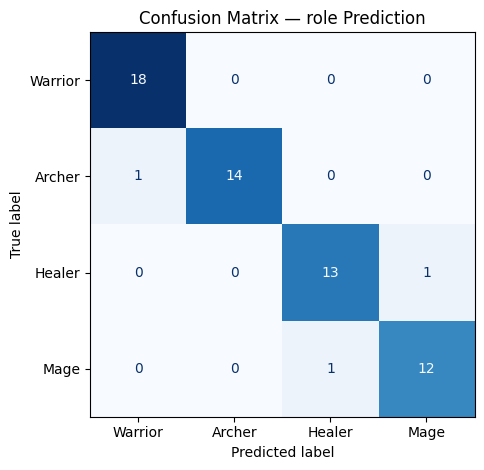

In [304]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Warrior', 'Archer', 'Healer', 'Mage'])

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Warrior', 'Archer', 'Healer', 'Mage'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — role Prediction')
plt.tight_layout()
plt.show()

In [305]:
# Accuracy, Precision, Recall, F1 — all in one
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['A', 'B', 'C', 'Fail']))

print('=== Individual Metrics ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2%}  — overall % correct')
print(f'Precision : {precision_score(y_test, y_pred, average="macro"):.2%}  — when it says a class, how often is it right?')
print(f'Recall    : {recall_score(y_test, y_pred, average="macro"):.2%}  — of the real class, how many did it catch?')
print(f'F1 Score  : {f1_score(y_test, y_pred, average="macro"):.2%}  — balance between precision & recall')

=== Classification Report ===
              precision    recall  f1-score   support

           A       1.00      0.93      0.97        15
           B       0.93      0.93      0.93        14
           C       0.92      0.92      0.92        13
        Fail       0.95      1.00      0.97        18

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60

=== Individual Metrics ===
Accuracy  : 95.00%  — overall % correct
Precision : 94.98%  — when it says a class, how often is it right?
Recall    : 94.62%  — of the real class, how many did it catch?
F1 Score  : 94.75%  — balance between precision & recall


## Decision Tree classifier:

=== Logistic Regression ===
Accuracy: 0.9500
              precision    recall  f1-score   support

      Archer       1.00      0.93      0.97        15
      Healer       0.93      0.93      0.93        14
        Mage       0.92      0.92      0.92        13
     Warrior       0.95      1.00      0.97        18

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60


=== Decision Tree Classifier ===
Accuracy: 0.9667
              precision    recall  f1-score   support

      Archer       1.00      1.00      1.00        15
      Healer       0.93      0.93      0.93        14
        Mage       0.92      0.92      0.92        13
     Warrior       1.00      1.00      1.00        18

    accuracy                           0.97        60
   macro avg       0.96      0.96      0.96        60
weighted avg       0.97      0.97      0.97        60


Accuracy Comparison:
  Decision T

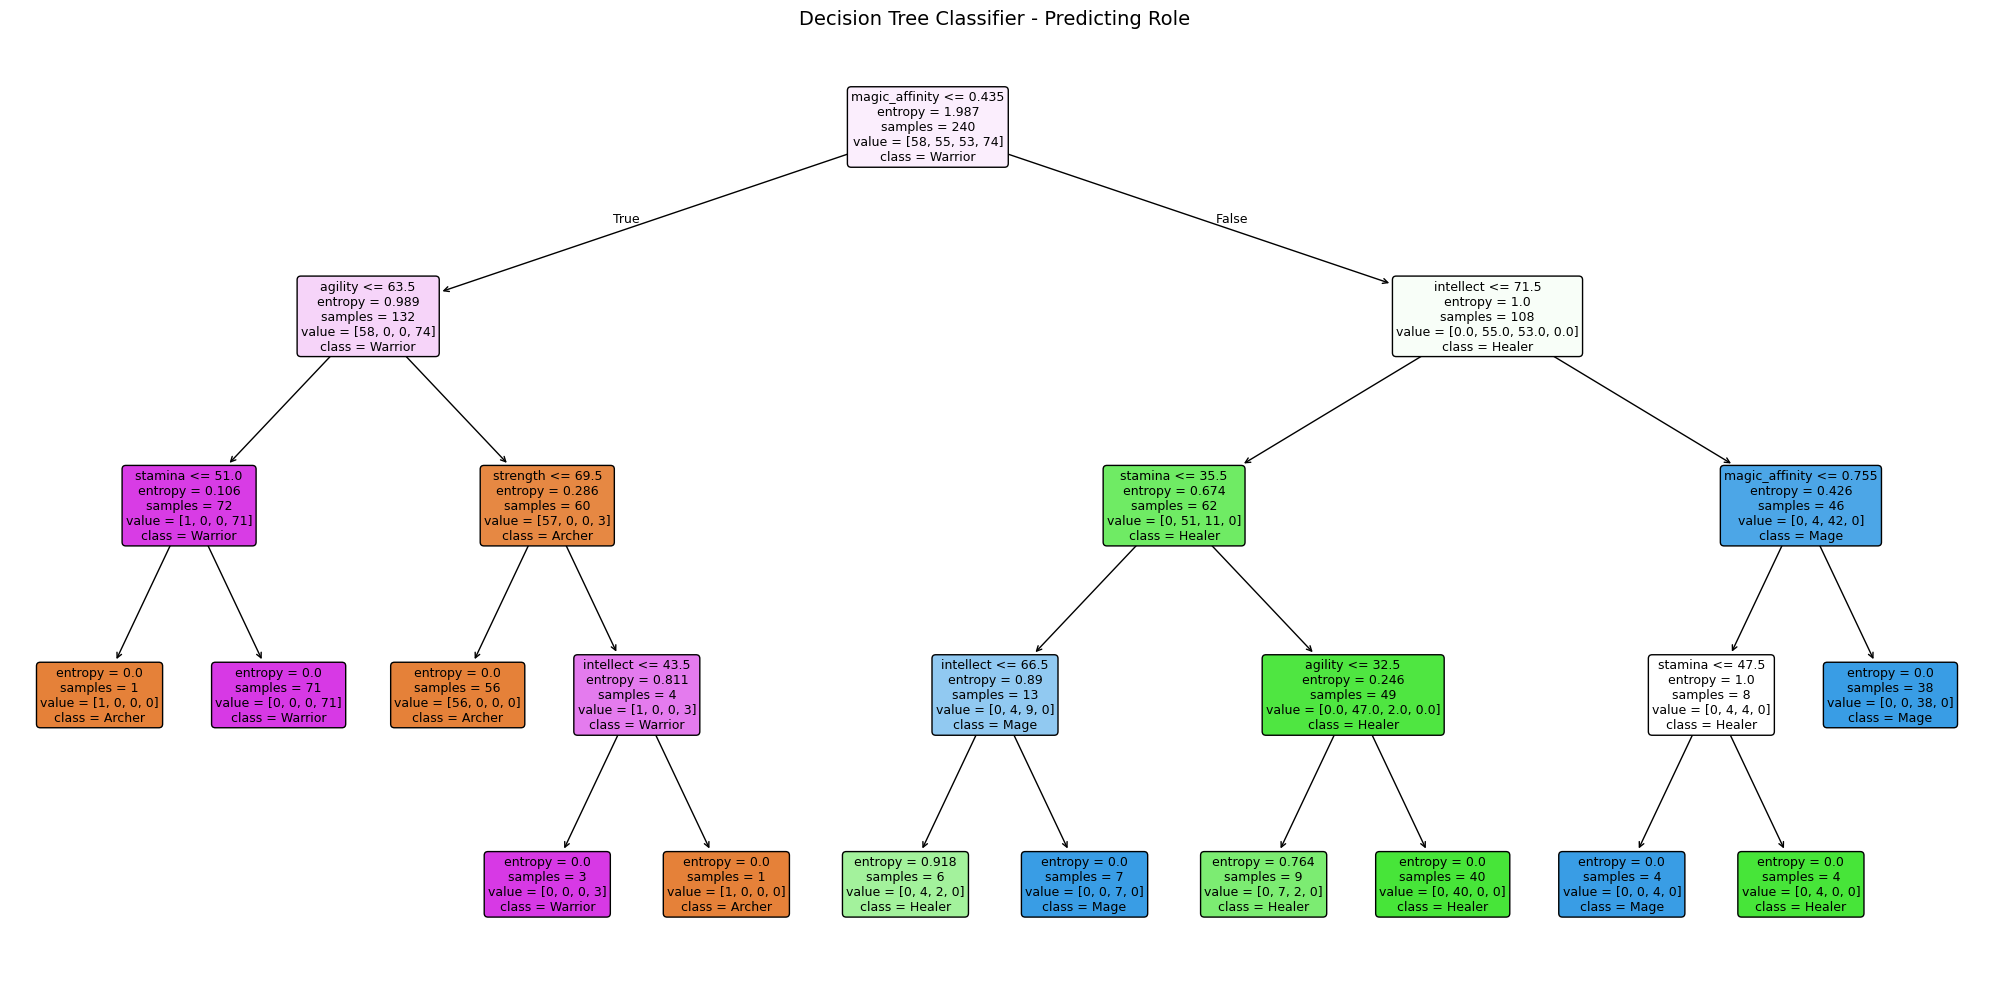

In [306]:
# ============================================================
# Task 4 — Classification: Predict role
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


X = df[['race', 'level', 'strength', 'agility','intellect','stamina','magic_affinity','years_training']]
X = pd.get_dummies(X, columns=['race'], drop_first=False)  # encode race
y = df['role']  # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

results = {}

# ============================================================
# 2. Logistic Regression
# ============================================================
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
results['Logistic Regression'] = accuracy_score(y_test, y_pred_log)

print("=== Logistic Regression ===")
print(f"Accuracy: {results['Logistic Regression']:.4f}")
print(classification_report(y_test, y_pred_log))

# ============================================================
# 3. Decision Tree Classifier
# ============================================================
tree_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
results['Decision Tree Classifier'] = accuracy_score(y_test, y_pred_tree)

print("\n=== Decision Tree Classifier ===")
print(f"Accuracy: {results['Decision Tree Classifier']:.4f}")
print(classification_report(y_test, y_pred_tree))

# ============================================================
# 4. Compare Accuracy Scores
# ============================================================
print("\nAccuracy Comparison:")
for model, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {model:<28} {score:.4f}")

# ============================================================
# 5. Confusion Matrix + Tree Plot (optional visuals)
# ============================================================
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_tree, labels=labels)
print("\nDecision Tree Confusion Matrix:")
print(pd.DataFrame(cm, index=labels, columns=labels))

plt.figure(figsize=(20, 10))
plot_tree(
    tree_clf,
    feature_names=X.columns,
    class_names=[str(c) for c in tree_clf.classes_],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Classifier - Predicting Role", fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_classifier_role.png', dpi=150, bbox_inches='tight')
plt.show()

# Task5 :

Average power_score by race:
race
Dragon    502.325000
Orc       445.575000
Elf       423.605455
Human     410.774194
Dwarf     401.025397
Name: power_score, dtype: float64

>>> Highest: Dragon (502.32)



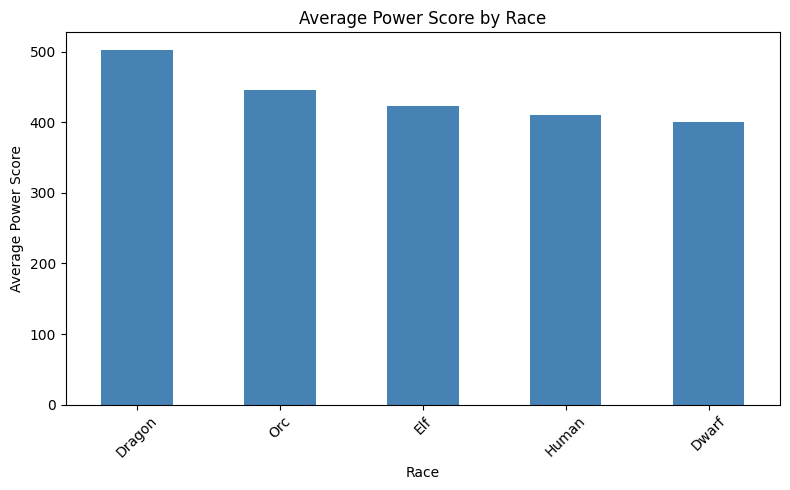

Average stats by role:
             level   strength    agility  intellect    stamina  \
role                                                             
Archer   26.917808  53.931507  80.493151  46.410959  55.767123   
Healer   27.449275  30.362319  40.144928  64.449275  49.014493   
Mage     23.409091  23.772727  40.757576  78.878788  35.196970   
Warrior  26.163043  75.369565  45.173913  33.228261  69.793478   

         magic_affinity  years_training  
role                                     
Archer         0.182329       14.397260  
Healer         0.705797       14.333333  
Mage           0.852576       15.712121  
Warrior        0.159674       13.673913  

Dominant stat per role (highest relative mean):
  Archer          -> agility
  Healer          -> level
  Mage            -> years_training
  Warrior         -> strength

Feature importance (Decision Tree Classifier predicting role):
  magic_affinity       0.5380
  agility              0.2390
  intellect            0.1203
  s

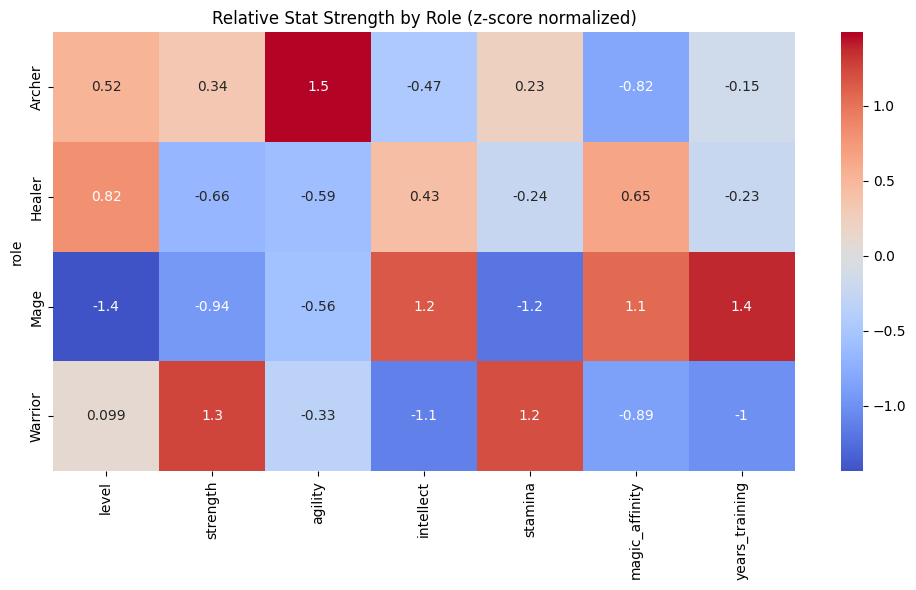

In [307]:
# ============================================================
# Task 5 — Analysis
# ============================================================

# --- 1. Which race has the highest average power_score? ---
avg_power_by_race = df.groupby('race')['power_score'].mean().sort_values(ascending=False)
print("Average power_score by race:")
print(avg_power_by_race)
print(f"\n>>> Highest: {avg_power_by_race.index[0]} ({avg_power_by_race.iloc[0]:.2f})\n")

# Optional bar chart
plt.figure(figsize=(8, 5))
avg_power_by_race.plot(kind='bar', color='steelblue')
plt.title('Average Power Score by Race')
plt.ylabel('Average Power Score')
plt.xlabel('Race')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avg_power_by_race.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# --- 2. Which stats are most linked to a specific role? ---
# ============================================================
stat_cols = ['level', 'strength', 'agility', 'intellect', 'stamina', 'magic_affinity', 'years_training']

# Average of each stat per role — shows which role excels where
role_stat_means = df.groupby('role')[stat_cols].mean()
print("Average stats by role:")
print(role_stat_means)

# Z-score normalize so stats on different scales are comparable
normalized = (role_stat_means - role_stat_means.mean()) / role_stat_means.std()

print("\nDominant stat per role (highest relative mean):")
for role in normalized.index:
    top_stat = normalized.loc[role].idxmax()
    print(f"  {role:<15} -> {top_stat}")

# --- Which feature is MOST effective overall (across all roles)? ---
# Uses feature_importances_ from the Decision Tree Classifier in Task 4
# Higher importance = the tree relies on that feature more to split/separate roles
print("\nFeature importance (Decision Tree Classifier predicting role):")
importance_ranked = sorted(zip(X.columns, tree_clf.feature_importances_), key=lambda x: -x[1])
for feat, imp in importance_ranked:
    print(f"  {feat:<20} {imp:.4f}")

most_effective_feature = importance_ranked[0][0]
print(f"\n>>> Most effective feature overall: {most_effective_feature}")

# Optional heatmap to visualize stat-role relationships
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(normalized, annot=True, cmap='coolwarm', center=0)
plt.title('Relative Stat Strength by Role (z-score normalized)')
plt.tight_layout()
plt.savefig('stat_role_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

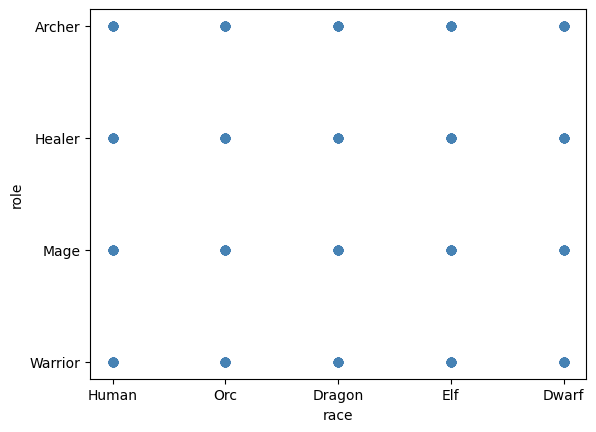

In [308]:
# Quick look at both features vs Salary
plt.scatter(df['race'], df['role'], color='steelblue')
plt.xlabel('race')
plt.ylabel('role')
plt.show()

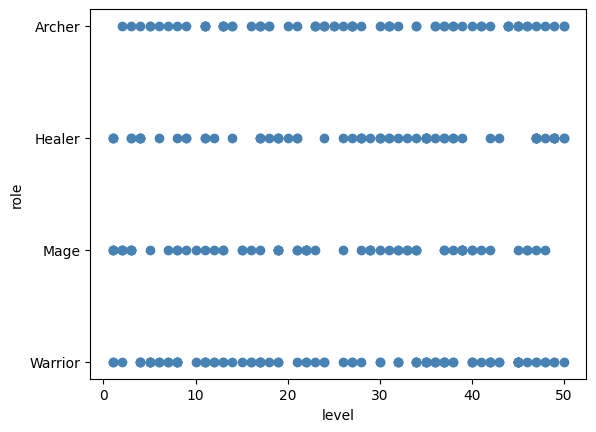

In [309]:
# Quick look at both features vs Salary
plt.scatter(df['level'], df['role'], color='steelblue')
plt.xlabel('level')
plt.ylabel('role')
plt.show()

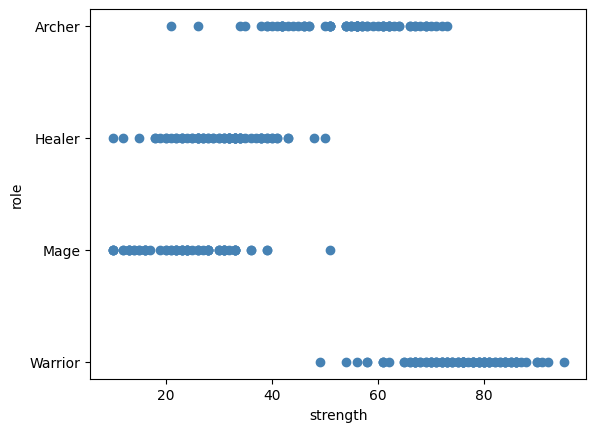

In [310]:
# Quick look at both features vs Salary
plt.scatter(df['strength'], df['role'], color='steelblue')
plt.xlabel('strength')
plt.ylabel('role')
plt.show()

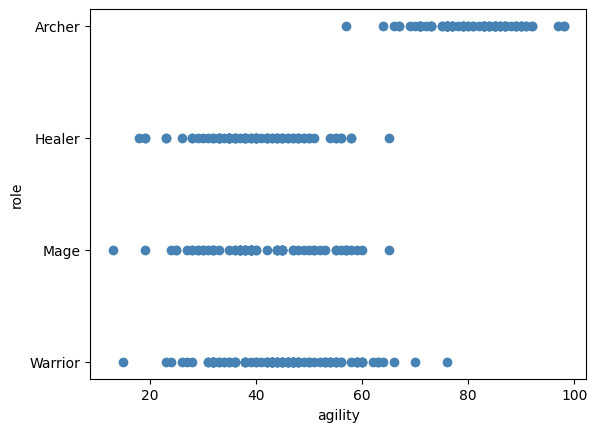

In [311]:
# Quick look at both features vs Salary
plt.scatter(df['agility'], df['role'], color='steelblue')
plt.xlabel('agility')
plt.ylabel('role')
plt.show()

# new model:

In [312]:
# ============================================================
# Random Forest Regressor — predicting power_score
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Features
X = df.drop(columns=['power_score'])

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Target MUST be numeric
y = df['power_score']

# Make sure power_score is numeric
y = pd.to_numeric(y, errors='coerce')

# Remove rows where target is missing/non-numeric
valid_rows = y.notna()
X = X.loc[valid_rows]
y = y.loc[valid_rows]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_test)

# R² Score
results['Random Forest Regressor'] = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor ===")
print(f"R² Score: {results['Random Forest Regressor']:.4f}")

# ============================================================
# Updated comparison across all models
# ============================================================

print("\nR² Score Comparison (all models):")

for model, score in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {model:<30} {score:.4f}")

# ============================================================
# Feature Importance
# ============================================================

print("\nFeature Importance (Random Forest):")

for feat, imp in sorted(
    zip(X.columns, rf_reg.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"  {feat:<20} {imp:.4f}")

=== Random Forest Regressor ===
R² Score: 0.6984

R² Score Comparison (all models):
  Decision Tree Classifier       0.9667
  Logistic Regression            0.9500
  Random Forest Regressor        0.6984

Feature Importance (Random Forest):
  level                0.6366
  years_training       0.2360
  intellect            0.0537
  magic_affinity       0.0333
  stamina              0.0133
  agility              0.0121
  strength             0.0066
  race_Dwarf           0.0048
  race_Elf             0.0014
  race_Human           0.0007
  role_Warrior         0.0005
  race_Orc             0.0004
  role_Mage            0.0003
  role_Healer          0.0002
